In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## Taylor Series (truncation error and round off error)

In [2]:
import math
def sin_taylor_1(x, num_terms):
    result = 0.0 # np.zeros_like(x)
    for n in range(0, num_terms):
        sign = (-1)**n
        power = 2*n + 1
        factorial = math.factorial(2*n+1)
        term = sign*(x**power)/factorial
        result = result + term
    return result

In [3]:
x = np.linspace(-7.5*np.pi, 7.5*np.pi, 100)

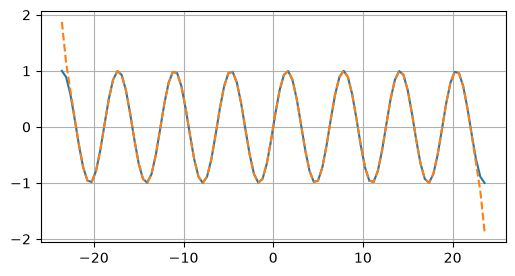

In [4]:
plt.close('all')
plt.figure(figsize=(6, 3))
plt.plot(x, np.sin(x))
plt.plot(x, sin_taylor_1(x, 30), '--')
plt.grid()
plt.show()

In [5]:
sin_taylor_1(0, 5)

0.0

In [6]:
sin_taylor_1(np.pi/6.0, 3)

0.5000021325887924

In [7]:
sin_taylor_1(np.pi, 50)

3.3280566969799443e-16

In [8]:
sin_taylor_1(np.pi/6, 5)

0.5000000000202799

### Taylor Approximations across a domain

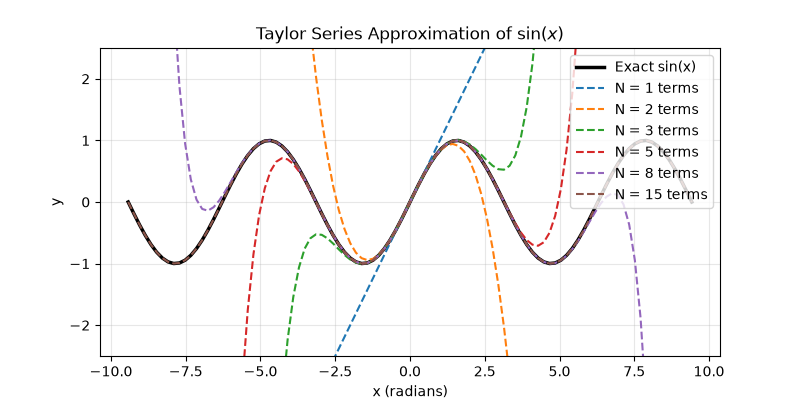

In [9]:
%matplotlib widget
# Taylor Approximations across a domain
x_domain = 3 * np.pi  # Plotting domain [-3pi, 3pi]
x_vals = np.linspace(-x_domain, x_domain, 100)
plt.close('all')
plt.figure(figsize=(8, 4))
plt.plot(x_vals, np.sin(x_vals), 'k-', linewidth=2.5, label='Exact sin(x)')

term_counts = [1, 2, 3, 5, 8, 15]
for n in term_counts:
    plt.plot(x_vals, sin_taylor_1(x_vals, n), '--', label=f'N = {n} terms')

plt.ylim(-2.5, 2.5)
plt.title(r'Taylor Series Approximation of $\sin(x)$')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

## At x = 0

In [10]:
# Parameters
x_eval = 0        # Specific x value to calculate error for

approx = sin_taylor_1(x_eval, 5)
exact = np.sin(x_eval)

print(f"x = {x_eval:.5f} rad")
print(f"5-term Approximation : {approx:.16f}")
print(f"Exact (np.sin)        : {exact:.16f}")
print(f"Absolute Error        : {abs(exact - approx):.16e}\n")

x = 0.00000 rad
5-term Approximation : 0.0000000000000000
Exact (np.sin)        : 0.0000000000000000
Absolute Error        : 0.0000000000000000e+00



## At x = pi/6

In [11]:
# Parameters
x_eval = np.pi/6        # Specific x value to calculate error for
approx = sin_taylor_1(x_eval, 5)
exact = np.sin(x_eval)

print(f"x = {x_eval:.5f} rad")
print(f"Approximation : {approx:.16f}")
print(f"Exact         : {exact:.16f}")
print(f"Absolute Error: {abs(exact - approx):.16e}\n")

x = 0.52360 rad
Approximation : 0.5000000000202799
Exact         : 0.4999999999999999
Absolute Error: 2.0279944390466653e-11



### At x = pi/6: Plot of error vs. no. of terms

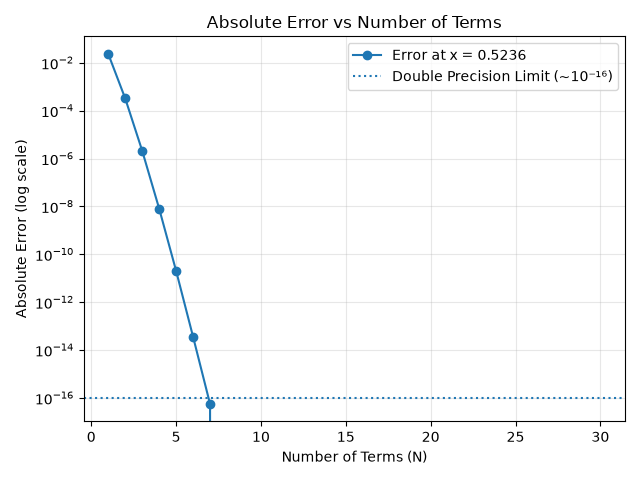

In [12]:
%matplotlib widget
# fig, ax2 = plt.subplots(1)
x_eval = np.pi/6 # np.pi/6       # Specific x value to calculate error for
max_terms = 30        # Max terms to check in error plot
# Plot 2: Absolute Error vs. Number of Terms (N)
n_range = np.arange(1, max_terms + 1)
errors = [abs(np.sin(x_eval) - sin_taylor_1(x_eval, n)) for n in n_range]

plt.close('all')
plt.semilogy(n_range, errors, 'o-', label=f'Error at x = {x_eval:.4f}')
plt.axhline(1e-16, linestyle=':', label='Double Precision Limit (~10⁻¹⁶)')
plt.title('Absolute Error vs Number of Terms')
plt.xlabel('Number of Terms (N)')
plt.ylabel('Absolute Error (log scale)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# plt.ylim(10**-(16), 10**-(15))
plt.tight_layout()
plt.show()

### 

### At x = 2*np.pi + np.pi/6 : Plot of error vs. no. of terms

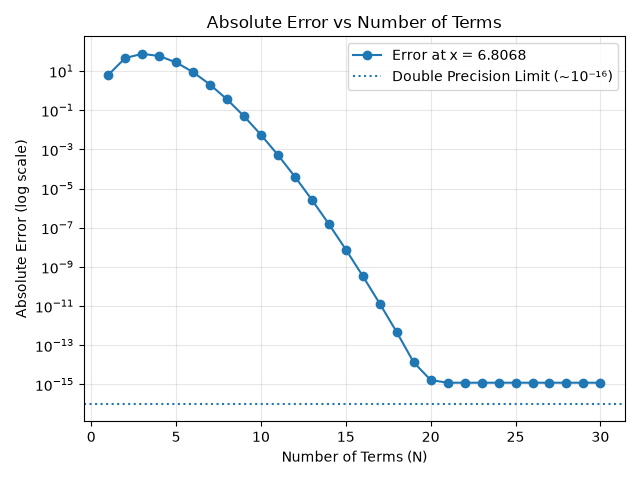

In [13]:
%matplotlib widget
# fig, ax2 = plt.subplots(1)
x_eval = +2*np.pi + np.pi/6         # Specific x value to calculate error for
max_terms = 30        # Max terms to check in error plot
# Plot 2: Absolute Error vs. Number of Terms (N)
n_range = np.arange(1, max_terms + 1)
errors = [abs(np.sin(x_eval) - sin_taylor_1(x_eval, n)) for n in n_range]

plt.close('all')
plt.semilogy(n_range, errors, 'o-', label=f'Error at x = {x_eval:.4f}')
plt.axhline(1e-16, linestyle=':', label='Double Precision Limit (~10⁻¹⁶)')
plt.title('Absolute Error vs Number of Terms')
plt.xlabel('Number of Terms (N)')
plt.ylabel('Absolute Error (log scale)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# plt.ylim(10**-(16), 10**-(15))
plt.tight_layout()
plt.show()

### At x = 4*np.pi + np.pi/6 : Plot of error vs. no. of terms

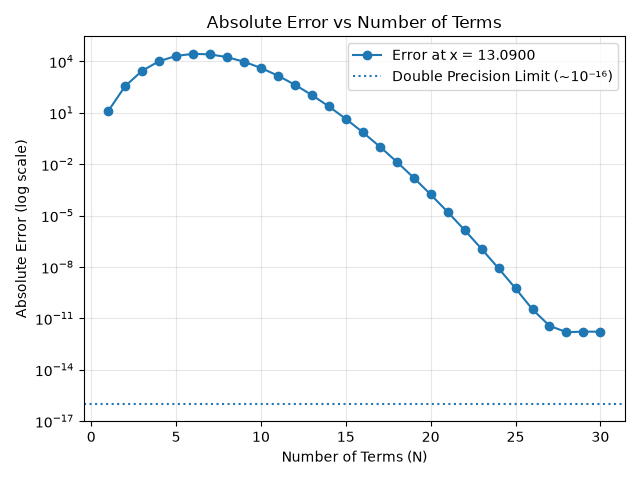

In [15]:
%matplotlib widget
# fig, ax2 = plt.subplots(1)
x_eval = 4*np.pi + np.pi/6         # Specific x value to calculate error for
max_terms = 30        # Max terms to check in error plot
# Plot 2: Absolute Error vs. Number of Terms (N)
n_range = np.arange(1, max_terms + 1)
errors = [abs(np.sin(x_eval) - sin_taylor_1(x_eval, n)) for n in n_range]

plt.close('all')
plt.semilogy(n_range, errors, 'o-', label=f'Error at x = {x_eval:.4f}')
plt.axhline(1e-16, linestyle=':', label='Double Precision Limit (~10⁻¹⁶)')
plt.title('Absolute Error vs Number of Terms')
plt.xlabel('Number of Terms (N)')
plt.ylabel('Absolute Error (log scale)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# plt.ylim(10**-(16), 10**-(15))
plt.tight_layout()
plt.show()

## Finding approximation of pi**2/6

In [16]:
ans = np.pi**2/6.0
print(ans)
ans_f32 = np.float32(np.pi**2/6.0)
print(f"{ans_f32:.20f}")

1.6449340668482264
1.64493405818939208984


## Question
true answer is pi**2/6
approximate this by the summation shown in two ways and find out which is better and **WHY?**
The two ways are:
1. Going from i = 1 to i = 100000
2. Going from i = 100000 to i = 1
## Find error: which is your summation - true_answer (np.pi**2/6)

$\sum_{i=1}^{100000} \frac{1}{i^2}$

In [17]:
result = np.float32(0.0)
for i in range(1, 100001):
    term = np.float32(1.0/i**2)
    result += term
print(result)
print("Error = ", result - ans)

1.6447253
Error =  -0.00020873547


$\sum_{i=1000}^{1} \frac{1}{i^2}$

In [18]:
result = np.float32(0.0)
for i in range(1000001, 0, -1):
    term = np.float32(1.0/i**2)
    result += term
print(result)
print("Error = ", result - ans)

1.644933
Error =  -1.0728836e-06


## Explanantion

Assume a float system with just 4 digits of storage in the mantissa (fraction): 

We have to add:

$1.644 \times 10^0$ + $1.234 \times 10^{-4}$

The computer first matches the exponent, and then adds the fraction part:

$$1.234 \times 10^{-4} \implies 0.0001\textcolor{red}{234} \times 10^0$$
Fitting to 4-Digit Storage Limit:
$$0.0001234 \times 10^0 \implies 0.0001 \times 10^0$$

Addition Step: 
Add the mantissas:$$1.644 \times 10^0 + 0.0001 \times 10^0 = 1.6441 \times 10^0$$

Here $0.234 \times 10^{-4}$ is lost as error. 